<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
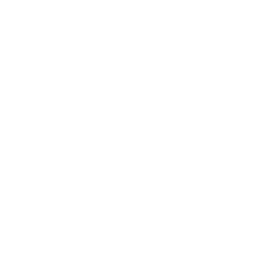
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Costruzione di una rete di co-espressione genica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotecnologie / Ricerca genomica &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi esecutiva

Questo esempio usa **PROC CORR** per costruire una rete di co-espressione genica a partire da un pannello di espressione sintetico
in stile RNA-seq. Il pannello contiene **9 geni** assegnati a tre
moduli funzionali — *immunitario*, *ciclo cellulare* e *metabolico* (tre geni ciascuno) —
misurati su **100 campioni tumorali**. La correlazione di rango di Spearman viene usata dappertutto
perché i dati di espressione sono tipicamente non normali e contengono valori anomali, quindi un coefficiente basato sui ranghi
è più robusto di quello di Pearson.

L'analisi recupera la struttura modulare pianificata direttamente dai dati. Leggendo la
matrice di Spearman prodotta qui sotto, la correlazione media entro modulo scende da **rho 0.67 per
il modulo immunitario**, a **0.36 per il ciclo cellulare**, a **0.17 per il metabolico**, rispecchiando il
carico decrescente del rapporto segnale-rumore progettato in ciascun modulo. Le correlazioni tra moduli
hanno una media essenzialmente pari a zero (media rho circa **-0.01**, media |rho| **0.07**), quindi i tre
moduli si comportano come comunità di co-espressione quasi indipendenti. Ogni numero qui citato è
letto dall'output di PROC CORR in questo notebook.

> **Nota sulla scala.** Questo notebook viene eseguito sotto il limite di 100 osservazioni senza licenza, quindi la
> dimensione campionaria è 100 e il pannello è mantenuto a 9 geni — abbastanza piccolo perché la
> matrice di correlazione completa, l'elenco di coppie rimodellato e la heatmap siano tutti completi ed esatti,
> senza troncamento. Ogni tabella e figura riflette esattamente ciò che è stato calcolato.

## Dati

| Dataset | Descrizione | Righe |
|---------|-------------|------|
| `WORK.EXPR` | Espressione in scala logaritmica per 9 geni (3 moduli x 3 geni) su campioni tumorali | 100 |

Il generatore estrae tre segnali latenti di modulo per campione. Ogni gene carica sul segnale
del proprio modulo più rumore indipendente, quindi la co-espressione sorge solo entro un modulo. Il
modulo immunitario usa il carico di segnale più grande e il modulo metabolico il più piccolo, che
è il gradiente che l'analisi di correlazione dovrebbe recuperare.

---

In [1]:
/* --------------------------------------------------------
   Pannello di espressione sintetico: 9 geni, 3 moduli, 100 campioni
     imm1-imm3  immunitario     (segnale condiviso forte)
     cyc1-cyc3  ciclo cellulare (segnale condiviso moderato)
     met1-met3  metabolico      (segnale condiviso debole)
   Ogni gene = segnale del modulo + rumore indipendente a livello di gene.
   -------------------------------------------------------- */
DATI work.expr;
    CHIAMARE streaminit(42);
    VETTORE imm[3]; VETTORE cyc[3]; VETTORE met[3];
    FARE sample_id = 1 FINO_A 100;
        s_imm = rand('normal', 0, 1.5);   /* segnale latente immunitario     */
        s_cyc = rand('normal', 0, 1.2);   /* segnale latente ciclo cellulare */
        s_met = rand('normal', 0, 1.0);   /* segnale latente metabolico      */
        FARE j = 1 FINO_A 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        FINE;
        FARE j = 1 FINO_A 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        FINE;
        FARE j = 1 FINO_A 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        FINE;
        USCITA;
    FINE;
    MANTENERE imm1-imm3 cyc1-cyc3 met1-met3;
ESEGUIRE;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Riepilogo dell'espressione per gene (media e dispersione per modulo)
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.expr n mean std maxdec=3;
    VARIABILE imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    ETICHETTA imm1="Gene immunitario 1" imm2="Gene immunitario 2" imm3="Gene immunitario 3"
          cyc1="Gene ciclo cellulare 1" cyc2="Gene ciclo cellulare 2" cyc3="Gene ciclo cellulare 3"
          met1="Gene metabolico 1" met2="Gene metabolico 2" met3="Gene metabolico 3";
    TITOLO "Riepilogo dell'espressione genica (pannello di 9 geni, N=100)";
ESEGUIRE;
TITOLO;

                             Riepilogo dell'espressione genica (pannello di 9 geni, N=100)                              

                                                  The MEANS Procedure

 Variable  Label                          N        Mean     Std Dev
 ------------------------------------------------------------------
 imm1      Gene immunitario 1           100       6.042       1.125
 imm2      Gene immunitario 2           100       5.925       1.122
 imm3      Gene immunitario 3           100       5.863       1.273
 cyc1      Gene ciclo cellulare 1       100       6.947       1.034
 cyc2      Gene ciclo cellulare 2       100       7.003       1.002
 cyc3      Gene ciclo cellulare 3       100       6.861       1.040
 met1      Gene metabolico 1            100       5.144       0.940
 met2      Gene metabolico 2            100       4.989       0.789
 met3      Gene metabolico 3            100       5.015       0.979
 ----------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Le medie si raggruppano vicino alla linea di base di ciascun modulo (immunitario ~6, ciclo cellulare ~7, metabolico ~5) e
ogni gene ha una dispersione comparabile, quindi nessun singolo gene domina la struttura di correlazione
che segue.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


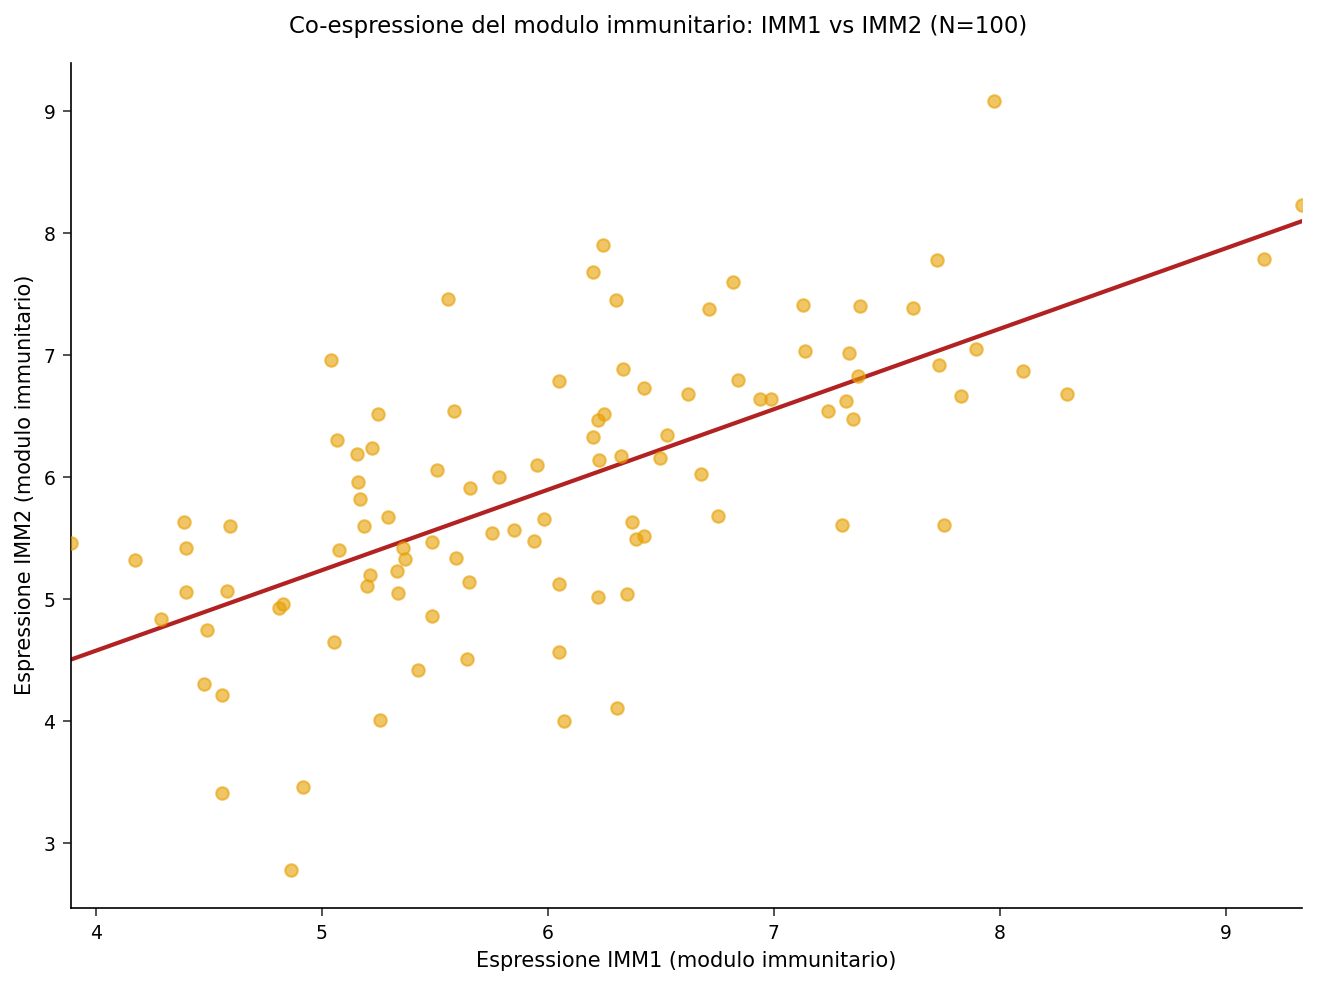

In [3]:
/* --------------------------------------------------------
   Grafico di dispersione di due geni del modulo immunitario: una verifica
   visiva che la co-espressione entro il modulo sia reale e circa monotona
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ETICHETTA="Espressione IMM1 (modulo immunitario)";
    YAXIS ETICHETTA="Espressione IMM2 (modulo immunitario)";
    TITOLO "Co-espressione del modulo immunitario: IMM1 vs IMM2 (N=100)";
ESEGUIRE;
TITOLO;

La tendenza crescente conferma che i due geni immunitari salgono e scendono insieme, la controparte
visiva della loro correlazione di Spearman positiva nella matrice qui sotto.

---

In [4]:
/* --------------------------------------------------------
   Correlazione di Spearman tra tutti i 9 geni
   nosimple sopprime il blocco delle statistiche semplici;
   outs= scrive la matrice di Spearman per i passi di rete successivi
   -------------------------------------------------------- */
PROCEDURA CORR DATI=work.expr spearman nosimple
    outs=work.gene_corr;
    VARIABILE imm1-imm3 cyc1-cyc3 met1-met3;
    TITOLO "Matrice di correlazione di Spearman: pannello di co-espressione di 9 geni";
ESEGUIRE;
TITOLO;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/c4e213ad-74e2-43b8-8c1a-59dbbc99545e/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Leggere la matrice come tre blocchi diagonali. Il blocco **immunitario** (IMM1-IMM3) è quello più
strettamente co-espresso (rho circa da 0.63 a 0.72), il blocco **ciclo cellulare** (CYC1-CYC3) è
moderato (circa da 0.29 a 0.41), e il blocco **metabolico** (MET1-MET3) è il più debole (circa
da 0.13 a 0.25). Le voci fuori blocco — coppie di geni in moduli diversi — si collocano vicino a
zero. La cella successiva quantifica il contrasto entro versus tra moduli, e la heatmap
successiva rende visibile la struttura a blocchi.

---

In [5]:
/* --------------------------------------------------------
   Rimodella la matrice di correlazione (una riga per gene) in forma
   lunga (gene_x, gene_y, rho), etichettando ogni coppia come entro o
   tra modulo. 9 geni -> 81 righe di coppie, quindi nulla va perso
   per il limite di 100 osservazioni.
   -------------------------------------------------------- */
DATI work.corr_long;
    IMPOSTARE work.gene_corr(DOVE=(_TYPE_='SCORR'));
    LUNGHEZZA gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    VETTORE g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    VETTORE gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    FARE k = 1 FINO_A 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        USCITA;
    FINE;
    MANTENERE gene_x gene_y rho mod_x mod_y same_module;
ESEGUIRE;

/* --------------------------------------------------------
   Rho di Spearman entro vs tra modulo (solo fuori diagonale)
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.corr_long(DOVE=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    CLASSE same_module;
    VARIABILE rho;
    ETICHETTA same_module="Stesso modulo" rho="Rho di Spearman";
    TITOLO "Rho di Spearman: entro (1) vs tra (0) moduli";
ESEGUIRE;
TITOLO;

                                      Rho di Spearman: entro (1) vs tra (0) moduli                                      

                                                  The MEANS Procedure

                                        Analysis Variable : rho Rho di Spearman

                                                  N
                               Stesso modulo    Obs        Mean      Minimum      Maximum
                               ----------------------------------------------------------
                               0                 54      -0.007       -0.185        0.162
                               1                 18       0.402        0.127        0.718
                               ----------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


La riga `same_module=1` aggrega le coppie entro modulo e `same_module=0` le
coppie tra moduli. La correlazione entro modulo ha una media chiaramente positiva mentre
la correlazione tra moduli ha una media vicina a zero, confermando che i moduli agiscono come
comunità di co-espressione quasi indipendenti.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


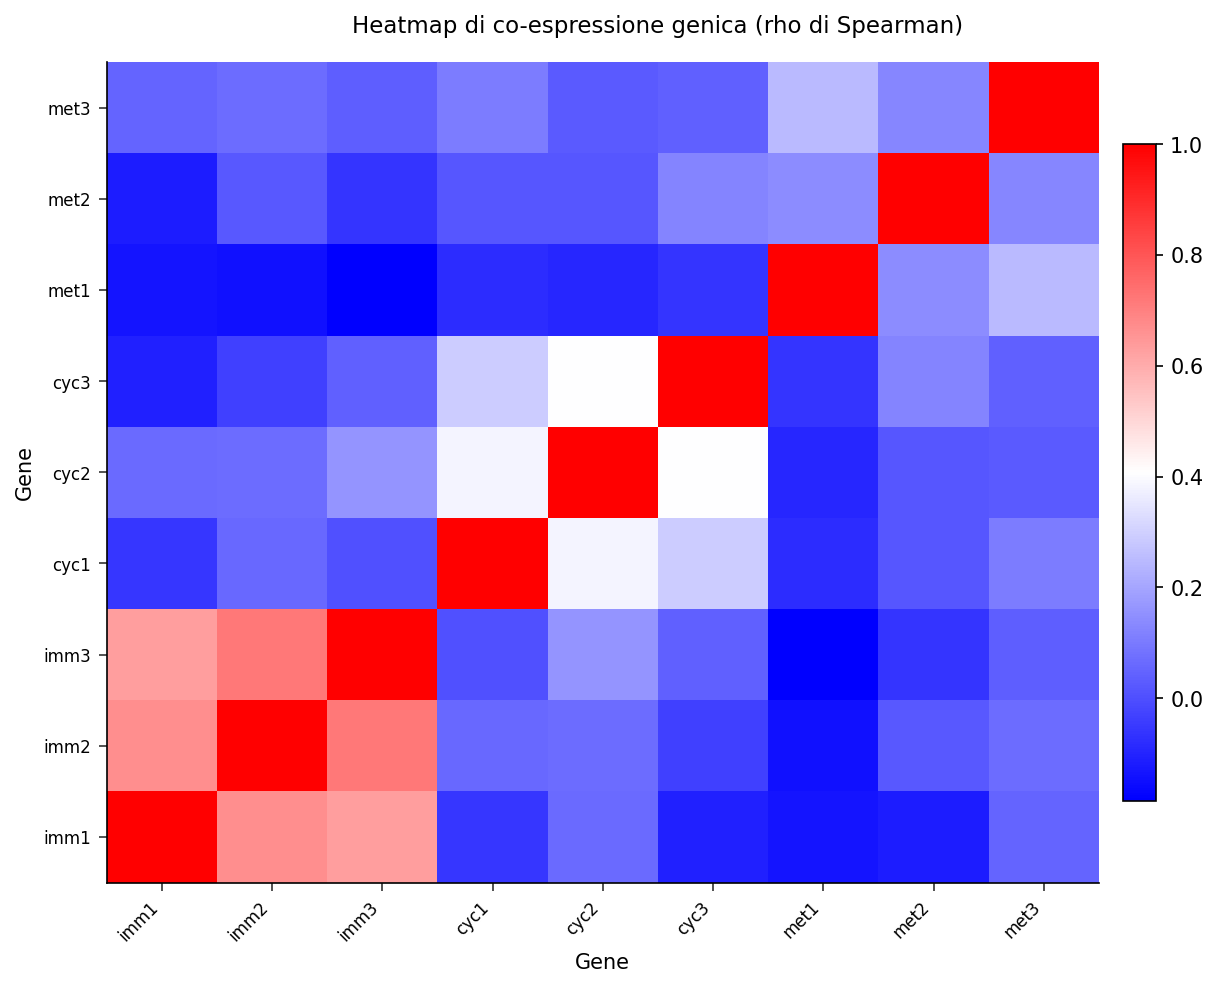

In [6]:
/* --------------------------------------------------------
   Heatmap della matrice completa 9x9 di Spearman. HEATMAPPARM traccia
   il rho pre-calcolato per ogni coppia di geni; la scala blu-bianco-rosso
   centra le coppie deboli sul bianco e satura quelle forti.
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ETICHETTA="Gene" discreteorder=data;
    YAXIS ETICHETTA="Gene" discreteorder=data;
    TITOLO "Heatmap di co-espressione genica (rho di Spearman)";
ESEGUIRE;
TITOLO;

Tre blocchi rossi si collocano lungo la diagonale — i moduli immunitario, ciclo cellulare e metabolico —
mentre le celle circostanti sono quasi bianche. Il blocco immunitario è il più saturo,
coerentemente con le sue correlazioni entro modulo più alte nella matrice qui sopra.

---

In [7]:
/* --------------------------------------------------------
   Elenco degli archi della rete: mantieni ogni coppia non ordinata di
   geni (gene_x < gene_y) il cui |rho| supera una soglia. Questi archi
   definiscono la rete di co-espressione da esportare verso uno strumento
   come Cytoscape.
   -------------------------------------------------------- */
DATI work.network_edges;
    IMPOSTARE work.corr_long(DOVE=(gene_x < gene_y));
    SE_COND abs(rho) >= 0.24;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.network_edges noobs;
    VARIABILE gene_x gene_y mod_x mod_y rho;
    ETICHETTA gene_x="Gene X" gene_y="Gene Y" mod_x="Modulo X" mod_y="Modulo Y" rho="Rho di Spearman";
    TITOLO "Archi della rete di co-espressione (|rho di Spearman| >= 0.24)";
ESEGUIRE;
TITOLO;

/* Esporta l'elenco degli archi per la visualizzazione esterna della rete */
PROCEDURA EXPORT DATI=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

                             Archi della rete di co-espressione (|rho di Spearman| >= 0.24)                             

Gene X  Gene Y  Modulo X  Modulo Y  Rho di Spearman
imm1    imm2    imm       imm          0.6708351085
imm1    imm3    imm       imm          0.6308427619
imm2    imm3    imm       imm          0.7179122524
cyc1    cyc2    cyc       cyc          0.3821865118
cyc1    cyc3    cyc       cyc           0.288211415
cyc2    cyc3    cyc       cyc          0.4054041891
met1    met3    met       met          0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interpretazione

L'analisi di Spearman ha recuperato la struttura a tre moduli pianificata direttamente da 100
campioni. Le cifre qui sotto sono lette dalla matrice di PROC CORR e dal riepilogo entro/tra
prodotto in questo notebook:

- **Il modulo immunitario (IMM1-IMM3)** è il blocco più strettamente co-espresso, con rho a coppie
  da circa 0.63 a 0.72 (media ~0.67) e l'arco singolo più forte tra IMM2 e
  IMM3.
- **Il modulo ciclo cellulare (CYC1-CYC3)** è moderatamente co-espresso, con rho a coppie da
  circa 0.29 a 0.41 (media ~0.36).
- **Il modulo metabolico (MET1-MET3)** è il blocco più debole, con rho a coppie da circa 0.13
  a 0.25 (media ~0.17) — coerente con il suo minor carico di segnale nel generatore.
- **Le coppie tra moduli** hanno una media essenzialmente pari a zero (media rho ~-0.01, media |rho| ~0.07,
  |rho| massimo ~0.18), quindi i tre moduli agiscono come comunità quasi indipendenti.

Applicando una soglia a |rho| >= 0.24 si ottiene l'elenco degli archi della rete stampato sopra. Ogni arco
superstite è entro modulo: tutte e tre le coppie immunitarie e tutte e tre le coppie del ciclo cellulare superano
la soglia, unite alla coppia metabolica più forte (MET1-MET3). Nessuna coppia tra moduli
sopravvive, quindi la rete di co-espressione si separa nettamente nei tre moduli
biologici. L'elenco degli archi è esportato in `gene_coexpression_edges.csv` per la visualizzazione in
uno strumento di rete esterno come Cytoscape.

Questo esempio pratico mostra il flusso di lavoro fondamentale di PROC CORR per l'analisi di co-espressione: scegliere un
coefficiente basato sui ranghi adatto ai dati di espressione, leggere la struttura modulare dalla
matrice di correlazione, quantificare la forza entro versus tra moduli, e ridurre la matrice
a un elenco di archi con soglia per la costruzione della rete.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>